In [1]:
import pandas as pd

In [2]:
VAF_data = pd.read_excel("./MTOR_VAFS.xlsx", sheet_name="Missense_only")

In [3]:
VAF_data.head()

,sample,chr,pos,ref,mut,mut_site,tum_globalvaf,gene,transcript,rna_desc,...,xfw_sum,xbw_sum,nfw_sum,nbw_sum,mutant_reads_sum,depth_sum,proportion_samples,subject,transcodon,Group
0,PD48433_m00002,1,11199395,G,A,1 11199395 G A,0.003113,MTOR,CCDS127.1,r.5173c>u,...,61,51,557,489,112,1046,0.033333,PD48433,-,CROSS
1,PD49231_m00022,1,11303348,T,A,1 11303348 T A,0.000782,MTOR,CCDS127.1,r.1312a>u,...,8,13,335,595,21,930,0.040816,PD49231,-,CROSS
2,PD47503ab,1,11177143,C,A,1 11177143 C A,0.000453,MTOR,CCDS127.1,r.7011g>u,...,2,4,147,166,6,313,0.022222,PD47503,-,CROSS
3,PD49362ai,1,11210195,C,A,1 11210195 C A,0.000603,MTOR,CCDS127.1,r.4635g>u,...,5,10,359,514,15,873,0.012500,PD49362,-,CROSS
4,PD47502r,1,11301732,C,A,1 11301732 C A,0.001144,MTOR,CCDS127.1,r.1496g>u,...,3,3,166,224,6,390,0.011111,PD47502,-,CROSS


In [4]:
VAF_sortened = VAF_data[["protein_desc", "summed_vaf", "Group"]]

In [5]:
VAF_sortened["Amino_acid"] = VAF_sortened['protein_desc'].str.extract(r'(\d+)')

/var/folders/vv/0521912d5_j4wpw2lwprbrzw0000gn/T/ipykernel_46315/675275363.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  VAF_sortened["Amino_acid"] = VAF_sortened['protein_desc'].str.extract(r'(\d+)')


In [6]:
VAF_sortened["Amino_acid"] = pd.to_numeric(VAF_sortened["Amino_acid"])

/var/folders/vv/0521912d5_j4wpw2lwprbrzw0000gn/T/ipykernel_46315/1329214076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  VAF_sortened["Amino_acid"] = pd.to_numeric(VAF_sortened["Amino_acid"])


In [7]:
lower_bound = 2156
upper_bound = 2469

VAF_sortened['Kinase'] = VAF_sortened['Amino_acid'].apply(lambda x: 'kinase' if lower_bound <= x <= upper_bound else 'nonkinase')

/var/folders/vv/0521912d5_j4wpw2lwprbrzw0000gn/T/ipykernel_46315/3952047387.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  VAF_sortened['Kinase'] = VAF_sortened['Amino_acid'].apply(lambda x: 'kinase' if lower_bound <= x <= upper_bound else 'nonkinase')


In [8]:
VAF_sortened["Kinase"].value_counts()

nonkinase    124
kinase        39
Name: Kinase, dtype: int64

In [9]:
VAF_sortened

,protein_desc,summed_vaf,Group,Amino_acid,Kinase
0,p.A1699V,0.218791,CROSS,1699,nonkinase
1,p.Y412F,0.044038,CROSS,412,nonkinase
2,p.V2312L,0.019169,CROSS,2312,kinase
3,p.A1520S,0.017182,CROSS,1520,nonkinase
4,p.Q473H,0.015385,CROSS,473,nonkinase
...,...,...,...,...,...
158,p.M50I,0.023411,EOX,50,nonkinase
159,p.I2501F,0.225706,EOX,2501,nonkinase
160,p.C1483W,0.016514,EOX,1483,nonkinase
161,p.M994I,0.019802,EOX,994,nonkinase


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

(0.0, 0.5)

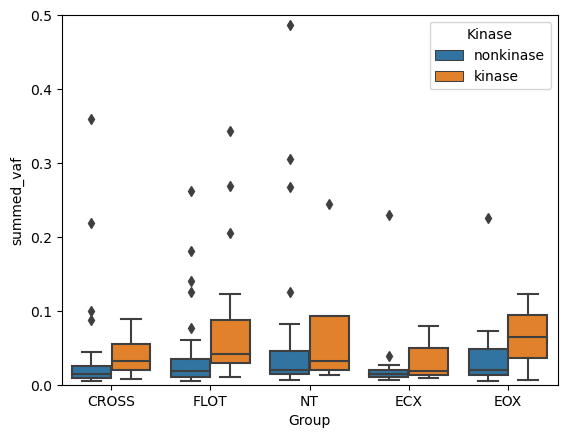

In [11]:
g = sns.boxplot(x = VAF_sortened["Group"], y = VAF_sortened["summed_vaf"], hue = VAF_sortened["Kinase"])

g.set_ylim(0, 0.5)

<AxesSubplot:xlabel='summed_vaf', ylabel='Count'>

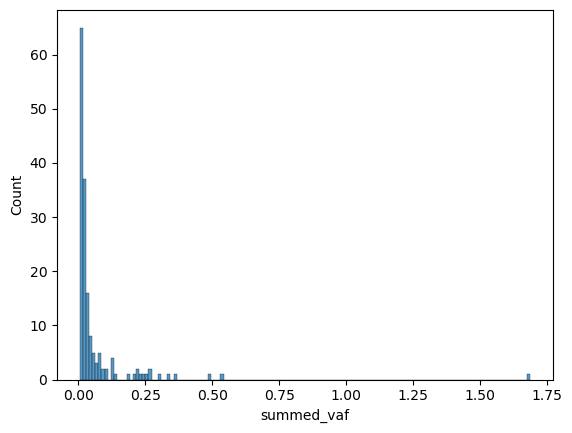

In [12]:
sns.histplot(VAF_sortened["summed_vaf"])

In [13]:
import numpy as np
from scipy.stats import mannwhitneyu

In [14]:
statistic, p_value = mannwhitneyu(VAF_sortened[VAF_sortened["Kinase"] == "kinase"]["summed_vaf"]
                                  , VAF_sortened[VAF_sortened["Kinase"] == "nonkinase"]["summed_vaf"], alternative='two-sided')

In [15]:
p_value

0.0002656575763749497

In [16]:
statistic

3356.0

In [17]:
def perform_mannwhitney(group):
    # Split data into two groups based on 'kinase'
    group1 = group[group['Kinase'] == 'kinase']['summed_vaf']
    group2 = group[group['Kinase'] == 'nonkinase']['summed_vaf']
    
    # Perform the test only if both groups have data
    if len(group1) > 0 and len(group2) > 0:
        stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
        return pd.Series({"Statistic": stat, "P-value": p_value})
    else:
        # Return NaN if there's not enough data
        return pd.Series({"Statistic": float('nan'), "P-value": float('nan')})

# Group by 'Group' and apply the function
results = VAF_sortened.groupby('Group').apply(perform_mannwhitney)


In [19]:
results

,Statistic,P-value
Group,,
CROSS,261.0,0.032048
ECX,27.0,0.654412
EOX,7.0,1.000000
FLOT,469.0,0.005220
NT,82.0,0.535149


/Users/davidshorthouse/anaconda3/envs/dsenv/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 63.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/davidshorthouse/anaconda3/envs/dsenv/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/davidshorthouse/anaconda3/envs/dsenv/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 59.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/davidshorthouse/anaconda3/envs/dsenv/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 30.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, U

(0.0, 0.5)

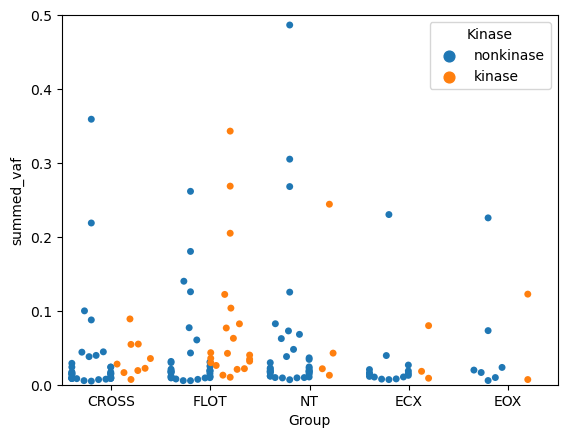

In [20]:
g = sns.swarmplot(x = VAF_sortened["Group"], y = VAF_sortened["summed_vaf"]
                  , hue = VAF_sortened["Kinase"], dodge = True)

g.set_ylim(0, 0.5)

In [89]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 5]

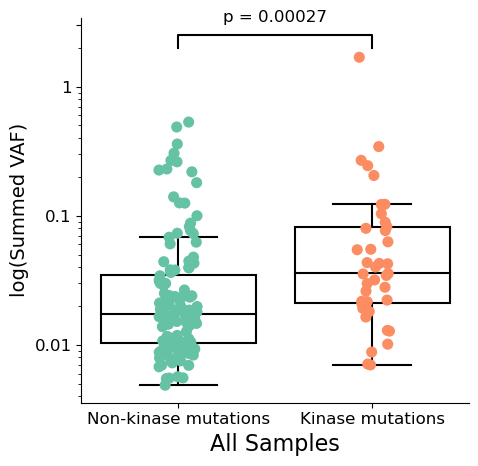

In [99]:
line_color = "k"

g = sns.boxplot(x = VAF_sortened["Kinase"], y = VAF_sortened["summed_vaf"]
                  , showfliers = False, palette = ["w", "w"],
    boxprops=dict(color=line_color, facecolor="w"),
    whiskerprops=dict(color=line_color),
    capprops=dict(color=line_color),
    medianprops=dict(color=line_color)
)

g = sns.stripplot(x = VAF_sortened["Kinase"], y = VAF_sortened["summed_vaf"]
                  ,dodge = True, size = 8, palette = sns.color_palette("Set2"))

g.set_yscale("log")

g.set_yticks([0.01, 0.1, 1, 3])
g.set_yticklabels(["0.01", "0.1", "1", ""], size = 12)

x1, x2 = 0, 1   # columns 'Sat' and 'Sun' (first column: 0, see plt.xticks())
y, h, col = 2, 0.5, 'k'

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.5, "p = 0.00027", ha='center', va='bottom', color=col, size = 12)

g.set_ylabel("log(Summed VAF)", size =14)
g.set_xticklabels(["Non-kinase mutations", "Kinase mutations"], size = 12)
g.set_xlabel("All Samples", size = 16)
sns.despine()

plt.savefig("MTOR_kinase_VAF_allsamples.pdf", bbox_inches = "tight")

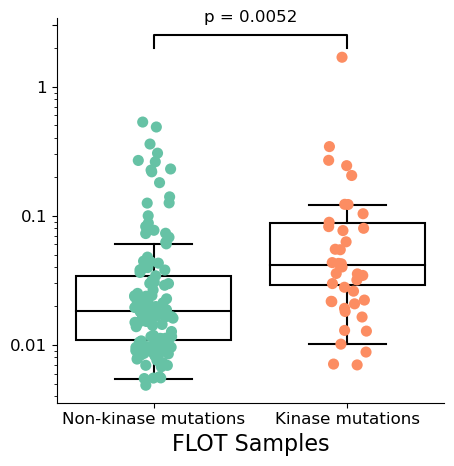

In [98]:
line_color = "k"

g = sns.boxplot(x = VAF_sortened[VAF_sortened["Group"] == "FLOT"]["Kinase"], y = VAF_sortened[VAF_sortened["Group"] == "FLOT"]["summed_vaf"]
                  , showfliers = False, palette = ["w", "w"],
    boxprops=dict(color=line_color, facecolor="w"),
    whiskerprops=dict(color=line_color),
    capprops=dict(color=line_color),
    medianprops=dict(color=line_color)
)

g = sns.stripplot(x = VAF_sortened["Kinase"], y = VAF_sortened["summed_vaf"]
                  ,dodge = True, size = 8, palette = sns.color_palette("Set2"))

g.set_yscale("log")

g.set_yticks([0.01, 0.1, 1, 3])
g.set_yticklabels(["0.01", "0.1", "1", ""], size = 12)

x1, x2 = 0, 1   # columns 'Sat' and 'Sun' (first column: 0, see plt.xticks())
y, h, col = 2, 0.5, 'k'

plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
plt.text((x1+x2)*.5, y+h+0.5, "p = 0.0052", ha='center', va='bottom', color=col, size = 12)

g.set_ylabel("log(Summed VAF)", size =14)
g.set_xticklabels(["Non-kinase mutations", "Kinase mutations"], size = 12)
g.set_xlabel("FLOT Samples", size = 16)
g.set_ylabel("")
sns.despine()

plt.savefig("MTOR_kinase_VAF_FLOTonly.pdf", bbox_inches = "tight")